# Plot Event 74 Hits and Clusters

This notebook loads the Event 74 CSV exports, filters the detector rows used in the original script, and renders the three 3D scatter plots as notebook figures and PDF files.


## Imports and plotting configuration

The colormap and normalization are kept consistent with the original script so the notebook reproduces the same visual style.


In [1]:
import csv
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from matplotlib.colors import LinearSegmentedColormap, PowerNorm
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

BASE_DIR = Path.cwd()

HIT_CSV_PATH = BASE_DIR / "../csv/event74_hits.csv"
CLUSTER_CSV_PATH = BASE_DIR / "../csv/event74_ntp_cluster.csv"
CLUS_TRK_CSV_PATH = BASE_DIR / "../csv/event74_ntp_clus_trk.csv"

HIT_PDF_PATH = BASE_DIR / "../images/event74_py.pdf"
CLUSTER_PDF_PATH = BASE_DIR / "../images/event74_ntp_cluster_py.pdf"
CLUS_TRK_PDF_PATH = BASE_DIR / "../images/event74_ntp_clus_trk_py.pdf"

BASE_CMAP = cm.get_cmap("viridis")
BLUE_TO_YELLOW = LinearSegmentedColormap.from_list(
    "viridis_blue_yellow",
    BASE_CMAP(np.linspace(0.25, 1.0, 256)),
)
ADC_NORM = PowerNorm(gamma=2.4, vmin=10, vmax=150, clip=True)


/tmp/ipykernel_39725/2473068860.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  BASE_CMAP = cm.get_cmap("viridis")


## Helper functions

These cells keep the original script structure but make each step easier to inspect interactively.


In [2]:
def cluster_norm(adcs: list[float]) -> PowerNorm:
    """Build a contrast stretch that adapts to the cluster ADC distribution.

    The mode is used as the lower edge because the cluster ADC values are
    strongly peaked. Using a percentile-based upper edge keeps a few large
    values from washing out the rest of the color range.
    """
    adc_mode = Counter(int(value) for value in adcs).most_common(1)[0][0]
    vmax = max(float(np.percentile(adcs, 99.5)), adc_mode + 1.0)
    return PowerNorm(gamma=2.4, vmin=adc_mode, vmax=vmax, clip=True)


def render(
    xs,
    ys,
    zs,
    adcs,
    output_path: Path,
    labels: tuple[str, str, str],
    norm: PowerNorm,
    invert_z: bool = False,
):
    """Render a single 3D scatter plot and save it to PDF.

    Returning the figure and axes lets the notebook display the plot inline
    while still preserving the script behavior of saving a high-resolution
    rasterized PDF copy.
    """
    fig = plt.figure(figsize=(11, 8))
    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(
        xs,
        ys,
        zs,
        c=adcs,
        cmap=BLUE_TO_YELLOW,
        norm=norm,
        s=1.2,
        linewidths=0,
        rasterized=True,
    )

    ax.set_xlabel(labels[0])
    ax.set_ylabel(labels[1])
    ax.set_zlabel(labels[2])
    ax.view_init(elev=24, azim=62)
    if invert_z:
        ax.invert_zaxis()
    ax.grid(False)
    ax.set_facecolor("white")
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.fill = False
        axis.pane.set_edgecolor((1, 1, 1, 0))

    fig.tight_layout()
    fig.savefig(output_path, dpi=450, bbox_inches="tight")
    return fig, ax


def load_rows(csv_path: Path, coordinates: tuple[str, str, str]) -> tuple[list[float], list[float], list[float], list[float]]:
    """Load the filtered detector rows used in the original plotting script.

    The script keeps only rows with `zelem == 1` and layers in the open
    interval `(7, 55)`. Those cuts are preserved exactly here so the notebook
    reproduces the same event view.
    """
    if not csv_path.exists():
        raise FileNotFoundError(f"Missing input CSV: {csv_path}")

    xs = []
    ys = []
    zs = []
    adcs = []

    with csv_path.open(newline="") as handle:
        reader = csv.DictReader(handle)
        for row in reader:
            zelem = float(row["zelem"])
            if zelem != 1:
                continue

            layer = float(row["layer"])
            if not (7 < layer < 55):
                continue

            xs.append(float(row[coordinates[0]]))
            ys.append(float(row[coordinates[1]]))
            zs.append(float(row[coordinates[2]]))
            adcs.append(float(row["adc"]))

    return xs, ys, zs, adcs


## Load the three datasets


In [3]:
hit_data = load_rows(HIT_CSV_PATH, ("plot_x", "plot_y", "plot_z"))
cluster_data = load_rows(CLUSTER_CSV_PATH, ("x", "y", "z"))
clus_trk_data = load_rows(CLUS_TRK_CSV_PATH, ("x", "y", "z"))

# The cluster-based CSV files are plotted with z on the horizontal axis
# to match the orientation used in the original script.
cluster_plot_data = (cluster_data[2], cluster_data[0], cluster_data[1], cluster_data[3])
clus_trk_plot_data = (clus_trk_data[2], clus_trk_data[0], clus_trk_data[1], clus_trk_data[3])

print(f"Loaded {len(hit_data[0]):,} hit rows")
print(f"Loaded {len(cluster_data[0]):,} cluster rows")
print(f"Loaded {len(clus_trk_data[0]):,} cluster-track rows")

Loaded 193,570 hit rows
Loaded 20,237 cluster rows
Loaded 1,641 cluster-track rows


## Render the hit plot


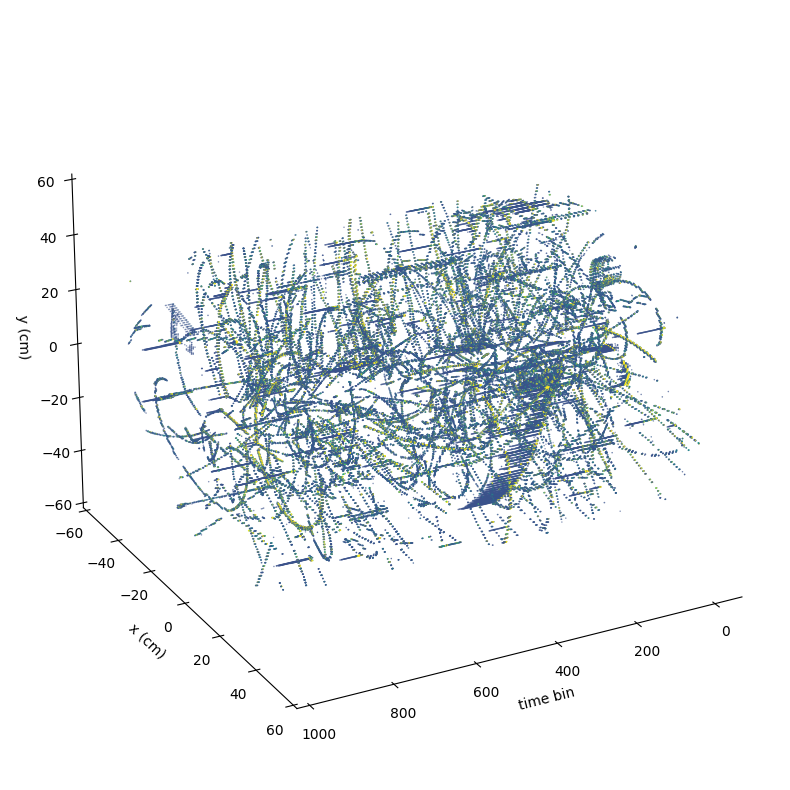

Saved /home/rog/sPHENIX/3D_ClusterFindingML/Visualizing/src/../images/event74_py.pdf


In [4]:
fig, ax = render(*hit_data, HIT_PDF_PATH, ("time bin", "x (cm)", "y (cm)"), ADC_NORM)
plt.show()
print(f"Saved {HIT_PDF_PATH}")


## Render the cluster plot


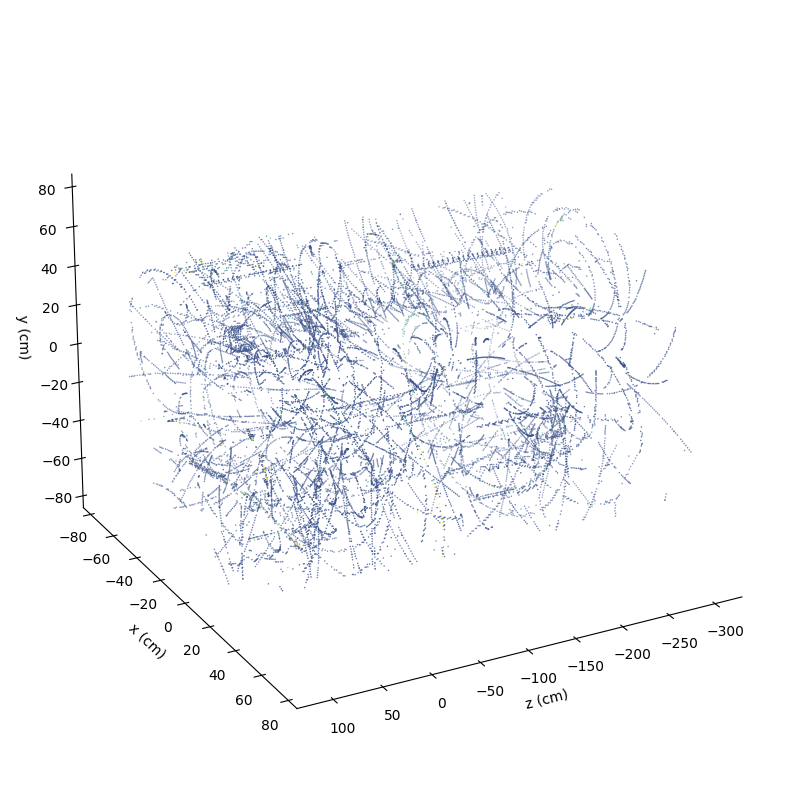

Saved /home/rog/sPHENIX/3D_ClusterFindingML/Visualizing/src/../images/event74_ntp_cluster_py.pdf


In [5]:
fig, ax = render(
    *cluster_plot_data,
    CLUSTER_PDF_PATH,
    ("z (cm)", "x (cm)", "y (cm)"),
    cluster_norm(cluster_data[3]),
)
plt.show()
print(f"Saved {CLUSTER_PDF_PATH}")


## Render the cluster-track plot


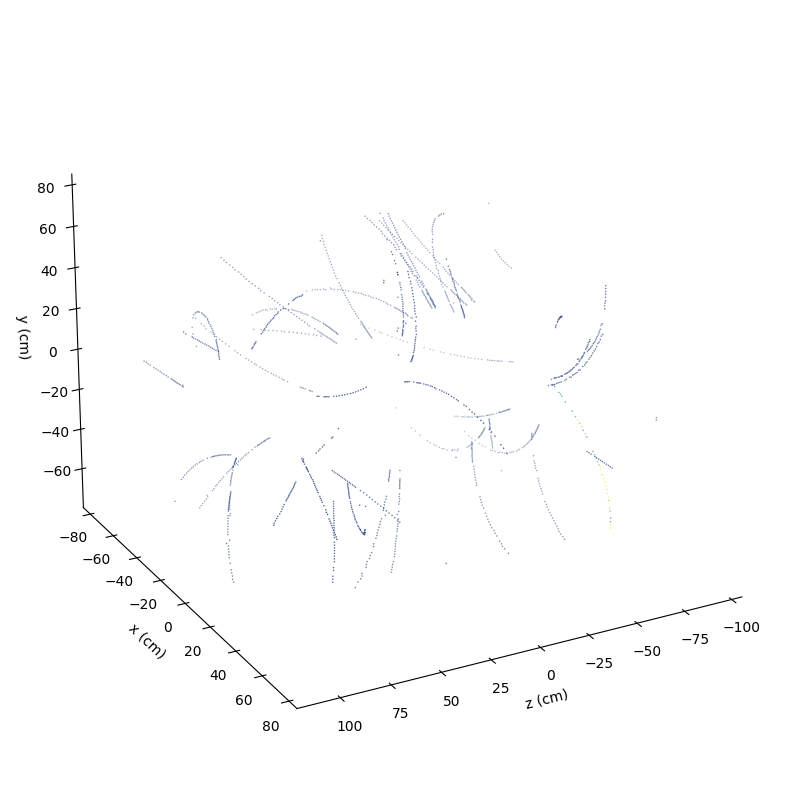

Saved /home/rog/sPHENIX/3D_ClusterFindingML/Visualizing/src/../images/event74_ntp_clus_trk_py.pdf


In [6]:
fig, ax = render(
    *clus_trk_plot_data,
    CLUS_TRK_PDF_PATH,
    ("z (cm)", "x (cm)", "y (cm)"),
    cluster_norm(clus_trk_data[3]),
)
plt.show()
print(f"Saved {CLUS_TRK_PDF_PATH}")
